<a href="https://colab.research.google.com/github/anu-peddada/EDA-Portfolio/blob/main/EDA_Portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AirPassengers EDA

**Project Title and Introduction**

Exploratory Data Analysis of Monthly Air Passenger Trends (1949–1960)

This project focuses on exploring historical trends in air passenger traffic from 1949 to 1960 using the AirPassengers.csv dataset. Air travel experienced significant growth during this period, and analyzing passenger numbers can reveal trends, seasonal patterns, and fluctuations over time.

--- Dataset Description ---

Source: Kaggle, uploaded by RakanNimer (AirPassengers.csv
)

Size: 144 rows × 2 columns (representing 12 years of monthly data).

--- Columns ---

Month: represents the year and month in the format YYYY-MM.

Passengers: the total number of passengers for that month.

Type: Numerical (Passengers) and Datetime (Month).

The main objective of this EDA project is to analyze the monthly air passenger data to:

* Identify overall trends and growth in air travel from 1949 to 1960.

* Detect seasonal patterns or recurring fluctuations within each year.

* Visualize changes over time and highlight any anomalies or significant shifts in passenger numbers.



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
uploaded = files.upload()

Saving AirPassengers.csv to AirPassengers.csv


In [ ]:
df = pd.read_csv('AirPassengers.csv')
print(df.head())

     Month  #Passengers
0  1949-01          112
1  1949-02          118
2  1949-03          132
3  1949-04          129
4  1949-05          121


**Data Loading & Cleaning**

*Checking for Missing Values*

We checked if there were any missing values in the datase.

In [ ]:
print(df.isnull().sum())

Month          0
#Passengers    0
dtype: int64


Missing values are places where data is empty or not recorded. Checking for them is important because they can affect statistics and graphs if we use incomplete data in calculations. For this dataset, there were no missing values after checking (so no changes were needed).

*Checking for Duplicates*

We also looked for duplicate rows:

In [ ]:
print(df.duplicated().sum())
df_no_duplicates = df.drop_duplicates()

0


Duplicate rows can cause errors in analysis because they make some data points count more than once. For example, duplicate monthly totals could give the wrong trend.

After cleaning the data, we transformed the Month column from plain text (strings) into a datetime format. This step makes the dataset easier to analyze over time because time series functions work only with proper datetime types.

In [ ]:
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

**Exploratory Analysis**

In [ ]:
df['#Passengers'].describe()

,#Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


Line Plot - The graph from 1949 to 1960 reveals a strong upward trend with consistent seasonal fluctuations. Each year shows a repeating pattern of peaks and troughs, indicating predictable cycles, likely due to seasonal demand. The overall increase from values near 100 to nearly 600 suggests sustained growth, while the regularity of the oscillations points to stable seasonality. No major outliers are visible, making this a clean dataset ideal for forecasting.

<Axes: xlabel='Month'>

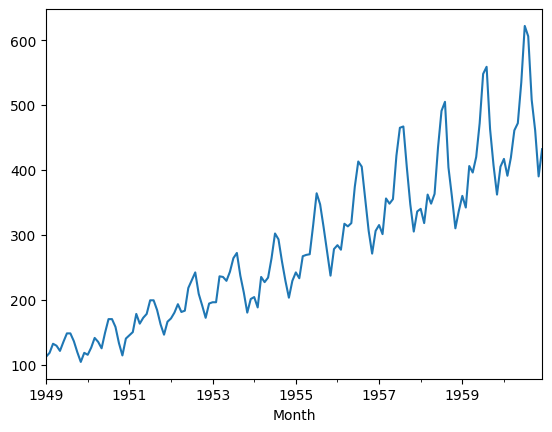

In [ ]:
df['#Passengers'].plot(kind='line')

Histogram - The histogram displays a right-skewed distribution, with most data values concentrated around 200 and gradually decreasing in frequency as values increase toward 600. The highest frequency occurs near 200, suggesting this is the most common range in the dataset. As values rise, the frequency drops steadily, indicating fewer occurrences of higher values. This pattern implies that while the dataset includes some large values, they are relatively rare compared to the lower ones.

<Axes: ylabel='Frequency'>

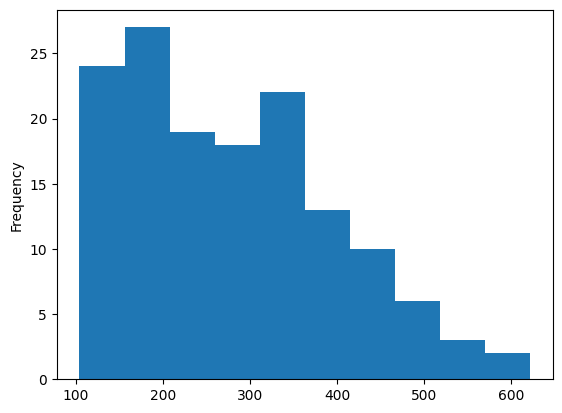

In [ ]:
df['#Passengers'].plot(kind='hist', bins=10)

Boxplot - The box plot illustrates the distribution of passenger numbers with a clear upward shift in central tendency. The median lies well above the lower quartile, indicating a right-skewed distribution. The interquartile range (IQR) is relatively wide, reflecting moderate variability in the data. There are no visible outliers, suggesting that most data points fall within a consistent range. This visualization confirms the presence of growth and dispersion in passenger counts over time.

<Axes: >

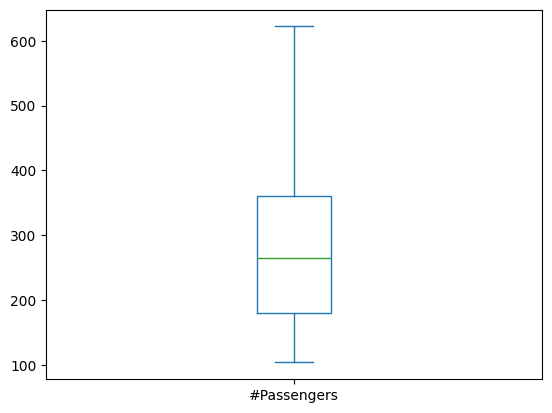

In [ ]:
df['#Passengers'].plot(kind='box')

Rolling Averages: because this data set is a time series data we nee to smooth short‑term fluctuations and highlight longer‑term trends:

<Axes: xlabel='Month'>

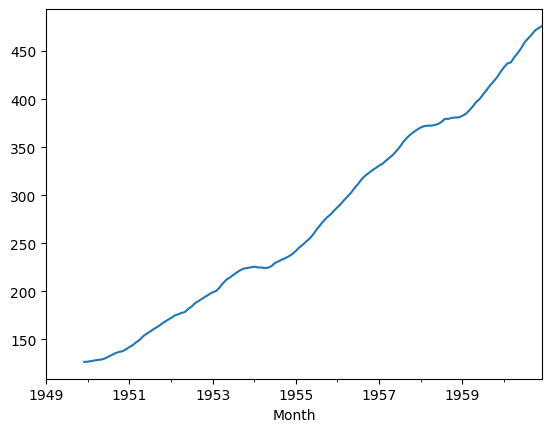

In [ ]:
rolling_mean = df['#Passengers'].rolling(window=12).mean()
rolling_mean.plot()

**Applying ARIMA model** As this data is a time series, we can apply a AutoRegressive Integrated Moving Average to achive time series forecasting.

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
model = ARIMA(df['#Passengers'], order=(1, 1, 1))
result = model.fit()
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:            #Passengers   No. Observations:                  144
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -694.341
Date:                Sun, 28 Dec 2025   AIC                           1394.683
Time:                        00:58:38   BIC                           1403.571
Sample:                    01-01-1949   HQIC                          1398.294
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4742      0.123     -3.847      0.000      -0.716      -0.233
ma.L1          0.8635      0.078     11.051      0.000       0.710       1.017
sigma2       961.9270    107.433      8.954      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


For forecasting the monthly air passenger counts, we selected an ARIMA(1,1,1) model because it is a standard approach for time series that have a trend and autocorrelation in past values. ARIMA models assume that the series can be made stationary through differencing and that the future behavior can be explained by its own past values (AR term) and past forecast errors (MA term) after removing trends via differencing. Before fitting the model, the data was differenced once to remove its non-stationary trend, satisfying a core assumption of ARIMA modeling that the mean and variance remain stable over time.
GeeksforGeeks
+1

The output shows significant autoregressive and moving average coefficients with p-values near zero, indicating they meaningfully contribute to the model. The Akaike Information Criterion (AIC) provides a baseline measure of model fit that can be compared with other model choices, with lower values suggesting better fit. Diagnostic tests such as the Ljung-Box test on residuals suggest no remaining autocorrelation, which supports that the model captures the main structure in the series. These results show that the ARIMA(1,1,1) model offers a reasonable starting point for forecasting and captures key time-dependent patterns in the monthly passenger data.

In [ ]:
predictions = result.predict(start=len(df), end=(len(df)+11))
print(predictions)

1961-01-01    475.735059
1961-02-01    454.996073
1961-03-01    464.830415
1961-04-01    460.167010
1961-05-01    462.378378
1961-06-01    461.329756
1961-07-01    461.827008
1961-08-01    461.591213
1961-09-01    461.703026
1961-10-01    461.650005
1961-11-01    461.675148
1961-12-01    461.663225
Freq: MS, Name: predicted_mean, dtype: float64


**Key Findings / Insights**

--- Model Insights ---
* The ARIMA(1,1,1) model captures the general trend and short-term patterns in the monthly AirPassengers data using past values and past errors.

* The AR and MA coefficients were statistically significant, showing the model terms meaningfully explain patterns in passenger counts.

* The AIC value provides a baseline measure of model fit — lower values indicate better relative fit when comparing different ARIMA models.

--- Practical Summary ---

* The ARIMA(1,1,1) model is a good baseline forecasting model for univariate time series data with trend behavior like AirPassengers.

* It helps you understand short term dependencies and gives interpretable coefficients.

* However, because of its assumptions and limitations (especially around seasonality, non-stationarity, and longer forecasts), more advanced models (such as seasonal ARIMA — SARIMA) or machine learning approaches might perform better for complex seasonal structures.

--- Assumptions Made ---

* Stationarity: The time series should be stationary (constant mean, variance, and autocorrelation over time). Differencing (the “I” term) is used to approximate this.
deepseekpro.org

* Linearity: ARIMA assumes relationships among past lags and forecast errors are linear.
Data Science

* Univariate context: The model uses only the target time series without incorporating external predictors.
